<a href="https://colab.research.google.com/github/Akhil-kayyamReddy/ML-Training-/blob/main/GENE_EXPRESSION_DISEASE_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading and Initial Inspection

In [21]:
import pandas as pd

X_data = pd.read_csv(r"/content/data.csv")
y_labels = pd.read_csv(r"/content/labels.csv")


merged_df = pd.merge(X_data, y_labels, on='Unnamed: 0', how='inner')


X = merged_df.drop(columns=['Unnamed: 0', 'Class']) # Drop sample ID and the target column itself
y = merged_df['Class']
print("X shape after alignment:", X.shape)
print("y shape after alignment:", y.shape)

X shape after alignment: (801, 20531)
y shape after alignment: (801,)


# Target Variable Preview

In [22]:
print(y.head())

0    PRAD
1    LUAD
2    PRAD
3    PRAD
4    BRCA
Name: Class, dtype: object


# Target Variable Extraction and Validation

In [23]:

print(y.head())
print("y shape:", y.shape)

0    PRAD
1    LUAD
2    PRAD
3    PRAD
4    BRCA
Name: Class, dtype: object
y shape: (801,)


# Feature Columns Inspection

In [24]:
print(X.columns[:5])

Index(['gene_0', 'gene_1', 'gene_2', 'gene_3', 'gene_4'], dtype='object')


# Feature Cleaning (Removing Identifier Column)

In [26]:
print("New X shape:", X.shape)

New X shape: (801, 20531)


# Data Validation and Class Distribution Analysis

In [27]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nClass distribution:\n")
print(y.value_counts())

Missing values in X: 0
Missing values in y: 0

Class distribution:

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


# Label Encoding of Target Variable

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Encoded labels sample:", y_encoded[:5])
print("Classes:", le.classes_)

Encoded labels sample: [4 3 4 4 0]
Classes: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']


# Feature Scaling using Standardization

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (801, 20531)


# Dimensionality Reduction using PCA

In [30]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy='mean')
X_scaled_imputed = imputer.fit_transform(X_scaled)

pca = PCA(n_components=100)
X_reduced = pca.fit_transform(X_scaled_imputed)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (801, 100)


# Train-Test Data Splitting

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y_encoded, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (640, 100)
Test shape: (161, 100)


# Logistic Regression Model Training and Evaluation

In [32]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=5000)
model_lr.fit(X_train, y_train)

accuracy = model_lr.score(X_test, y_test)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 1.0


# Model Evaluation using Classification Metrics

In [33]:
from sklearn.metrics import classification_report

y_pred = model_lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        29
           4       1.00      1.00      1.00        29

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



# Model Validation using Cross-Validation

In [34]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_lr, X_reduced, y_encoded, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.99378882 1.         1.         0.99375    1.        ]
Mean accuracy: 0.9975077639751554


# Random Forest Model Training and Performance Evaluation

In [35]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

rf_accuracy = model_rf.score(X_test, y_test)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9751552795031055


# Model Performance Comparison

In [36]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 0.9751552795031055


# Cancer Type Distribution Visualization

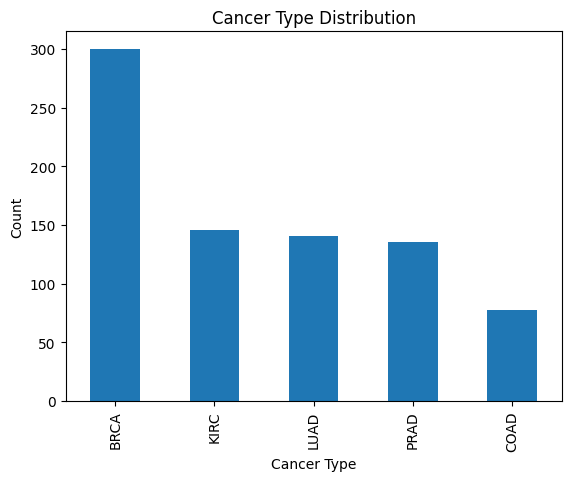

In [37]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Cancer Type Distribution")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

# Feature Importance Analysis using Random Forest

In [38]:
import pandas as pd
import numpy as np

# Train RF on original scaled data (not PCA)
model_rf_full = RandomForestClassifier(random_state=42)
model_rf_full.fit(X_scaled, y_encoded)

# Get feature importance
importances = model_rf_full.feature_importances_

# Convert to DataFrame
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})

# Top 10 important genes
top_features = feature_importance_df.sort_values(by='importance', ascending=False).head(10)

print(top_features)

          feature  importance
14092  gene_14092    0.013081
15987  gene_15987    0.010757
8099    gene_8099    0.009729
7964    gene_7964    0.009284
7896    gene_7896    0.009193
5578    gene_5578    0.008598
1122    gene_1122    0.008332
16169  gene_16169    0.008284
5598    gene_5598    0.007933
14427  gene_14427    0.007054


# Visualization of Top Important Features (Genes)

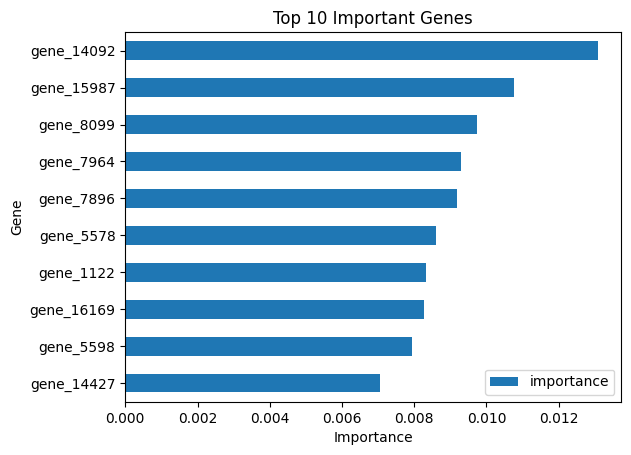

In [39]:
import matplotlib.pyplot as plt

top_features.plot(kind='barh', x='feature', y='importance')
plt.title("Top 10 Important Genes")
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.gca().invert_yaxis()
plt.show()

In [40]:
print("Best Model: Logistic Regression")
print("Recommended Feature Approach: PCA (100 components)")
print("Key Insight: A small subset of genes significantly influences cancer classification")

Best Model: Logistic Regression
Recommended Feature Approach: PCA (100 components)
Key Insight: A small subset of genes significantly influences cancer classification
